In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../../python_files/')
import qubits
import pulses

### Transmonin määrittely

In [2]:
E_C = 0.3*2*np.pi #Varausenergia (GHz)
E_J = 8*2*np.pi #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [3]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[  0.          25.48860139  48.57030326  69.5813038   82.4548144
 109.4189376  110.44497738 160.29841201 160.30648659 227.12458838
 227.12460681]


## Simulaatio

In [4]:
f_1 = qubit.frequency*1.2 #Ajotaajuudet
f_2 = qubit.frequency*1.4
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

dim = 7 #Hilbert-avaruuden dimensio

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

In [ ]:
def find_params(q,A,evolution,f_rabi,c_guess,lims,scale):

    #Rajat AC-stark siirtymälle
    min_range = lims[0]
    max_range = lims[1]
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]
    c_vals=[]
    
    for i in range(min_range, max_range):
        f_1_shifted=f_1*(c_guess+i/scale)
        f_2_shifted=f_2*(c_guess+i/scale)

        c_vals.append(c_guess+i/scale)
        delta=q.frequency-2*f_1_shifted+f_2_shifted #AC-stark siirtymä
        AC_stark_vals.append(delta)

        if A < 2.3:
            sim_vals = pulses.sim_3_part_pulses(f_1_shifted,f_ef,A,evolution,dim,f_rabi,t_ramp=5,U_f=10,f_2=f_2_shifted,K=200)
        elif A < 2.9:
            sim_vals = pulses.sim_3_part_pulses(f_1_shifted,f_ef,A,evolution,dim,f_rabi,t_ramp=5,U_f=5,f_2=f_2_shifted,K=200)
        else:
            sim_vals = pulses.sim_3_part_pulses(f_1_shifted,f_ef,A,evolution,dim,f_rabi,t_ramp=5,U_f=1,f_2=f_2_shifted,K=200)
        
        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    plt.figure()
    plt.plot(AC_stark_vals, max_e_vals)
    plt.xlabel("delta=ω_q-2ω_1+ω_2 (GHz)")
    plt.ylabel("Suurin e-tason todennäköisyys")
    plt.show()
    
    index=np.argmax(max_e_vals)
    c=c_vals[index]
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    pi_pulse=pulse_times[index]
    
    return(c,pi_pulse,[e_max,f_max],max_e_vals)

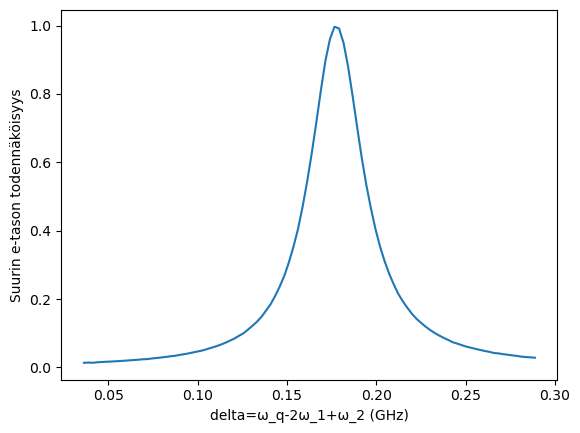

Amplitudi (GHz): 2.039088111159714
AC-stark siirtymä (GHz): 0.9930733865293206
E-tason suurin todennäköisyys: 0.9969169160461923
Pulssin pituus (ns): 196.17175076443056
Rabi-taajuus (fourier):  0.002553298826079879


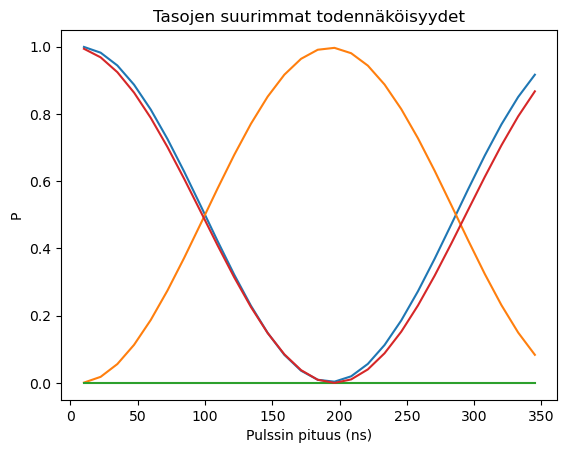

---------------------------------------------


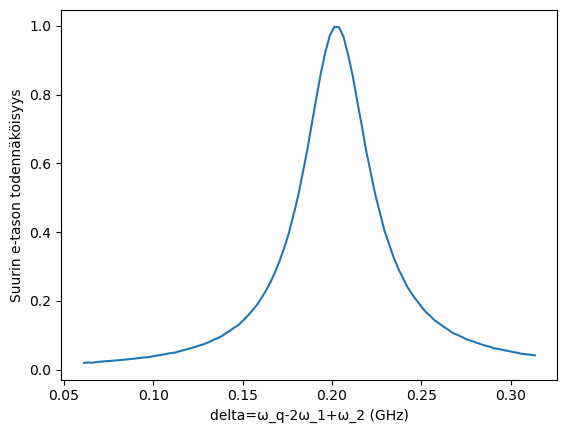

Amplitudi (GHz): 2.1732386447886425
AC-stark siirtymä (GHz): 0.9920967260182538
E-tason suurin todennäköisyys: 0.9974480739983631
Pulssin pituus (ns): 159.0840206678187
Rabi-taajuus (fourier):  0.0031091146537931837


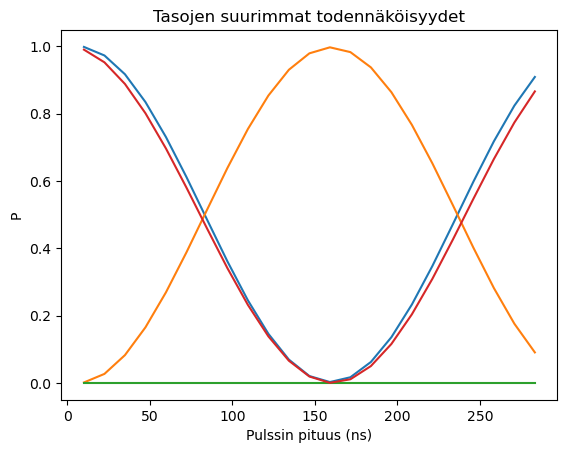

---------------------------------------------


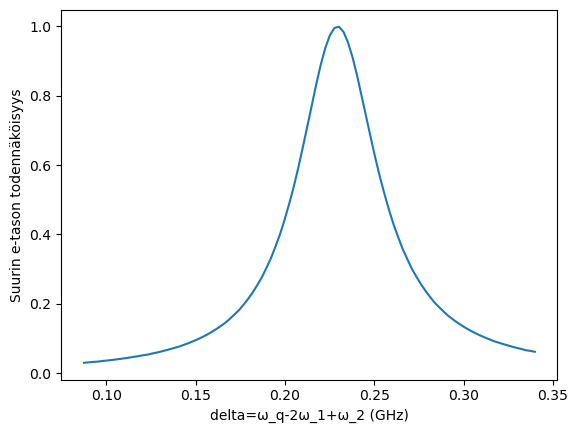

Amplitudi (GHz): 2.307389178417571
AC-stark siirtymä (GHz): 0.9909671201993773
E-tason suurin todennäköisyys: 0.9989779966907044
Pulssin pituus (ns): 134.37830158652045
Rabi-taajuus (fourier):  0.003729891145446168


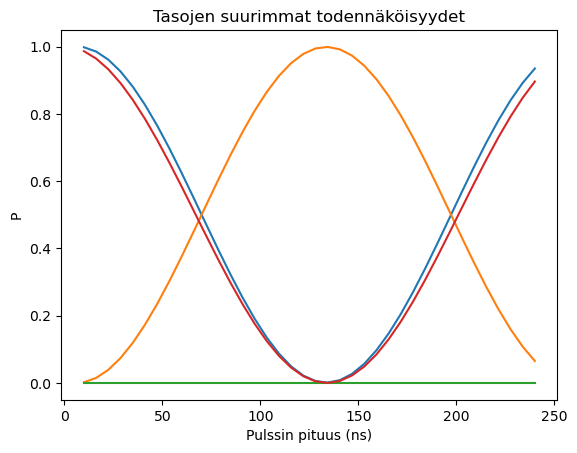

---------------------------------------------


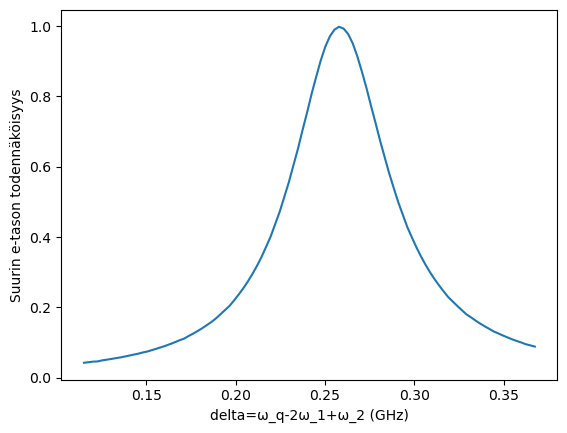

Amplitudi (GHz): 2.4415397120464997
AC-stark siirtymä (GHz): 0.989884569072691
E-tason suurin todennäköisyys: 0.999795415969553
Pulssin pituus (ns): 115.83717486964673
Rabi-taajuus (fourier):  0.004927119353670419


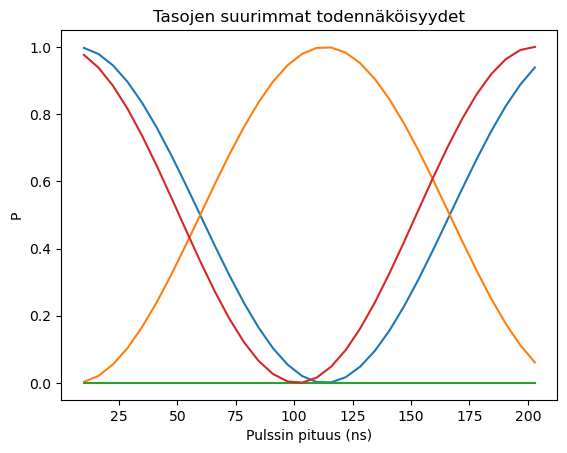

---------------------------------------------


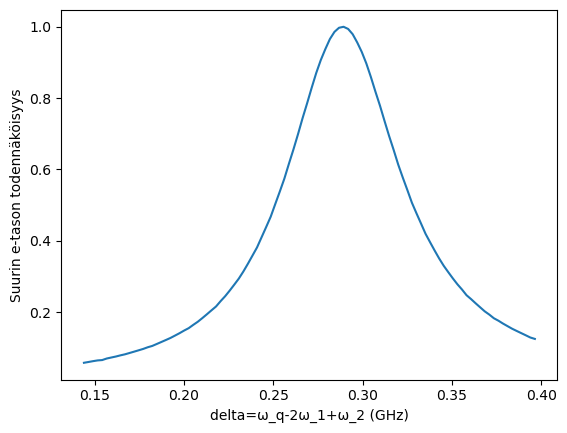

Amplitudi (GHz): 2.575690245675428
AC-stark siirtymä (GHz): 0.9886490726381949
E-tason suurin todennäköisyys: 0.999719281498736
Pulssin pituus (ns): 97.26894863382229
Rabi-taajuus (fourier):  0.005812449728711454


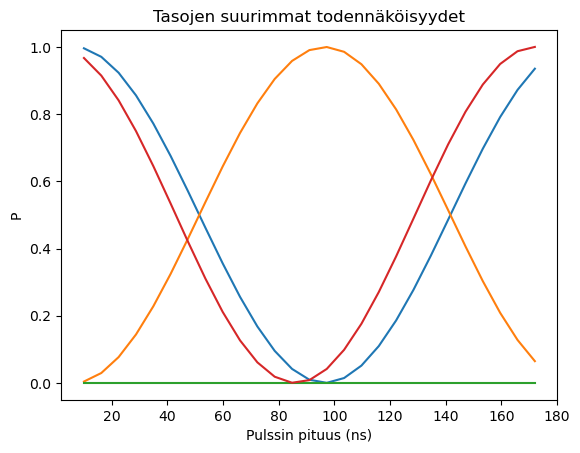

---------------------------------------------


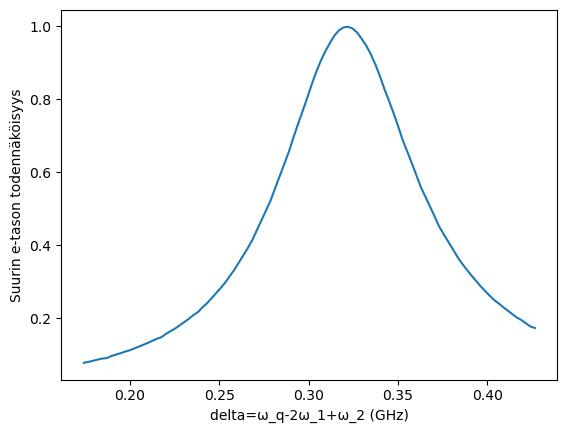

Amplitudi (GHz): 2.7098407793043564
AC-stark siirtymä (GHz): 0.9873606308958891
E-tason suurin todennäköisyys: 0.9998386946345065
Pulssin pituus (ns): 84.89956768479678
Rabi-taajuus (fourier):  0.006788751817781148


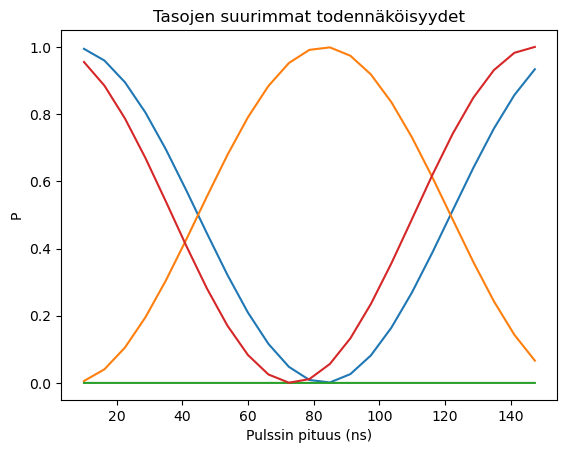

---------------------------------------------


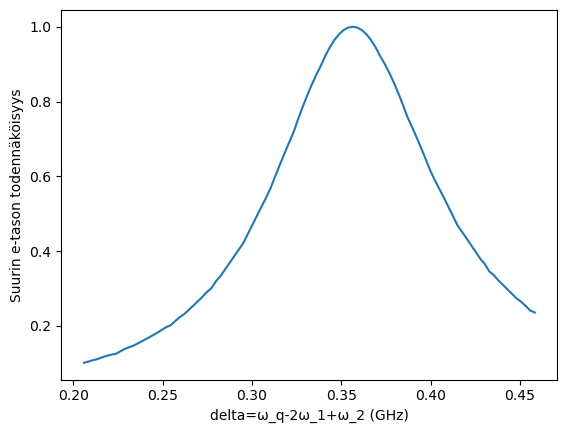

Amplitudi (GHz): 2.8439913129332854
AC-stark siirtymä (GHz): 0.9860192438457734
E-tason suurin todennäköisyys: 0.9999632528679934
Pulssin pituus (ns): 72.50121795683864
Rabi-taajuus (fourier):  0.00792063772728974


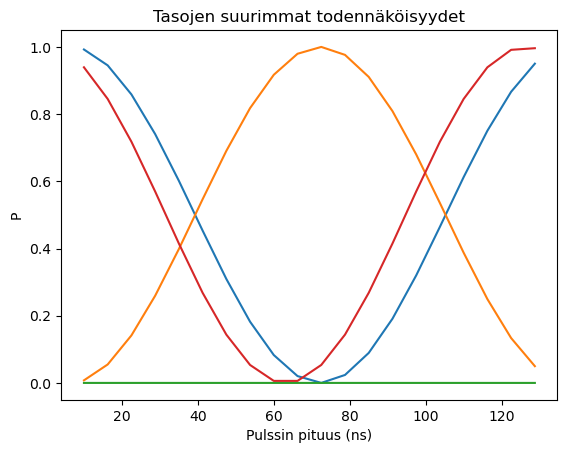

---------------------------------------------


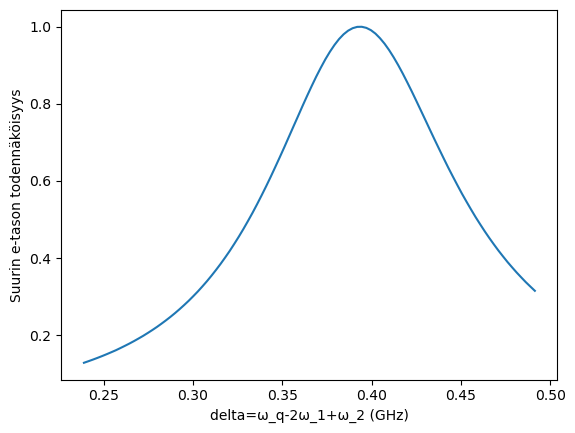

Amplitudi (GHz): 2.9781418465622136
AC-stark siirtymä (GHz): 0.9845249114878482
E-tason suurin todennäköisyys: 0.9996990712609413
Pulssin pituus (ns): 62.58071022695719
Rabi-taajuus (fourier):  0.009160229560761141


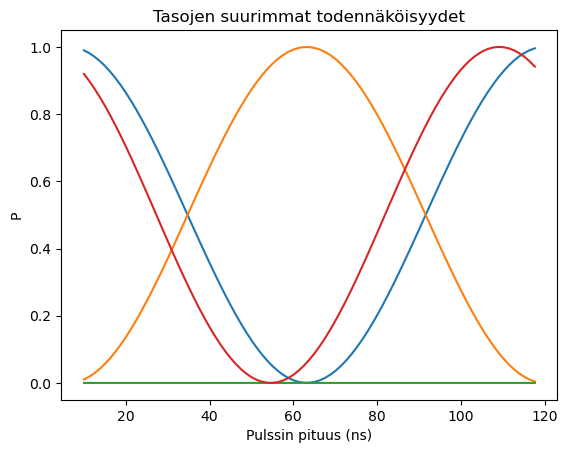

---------------------------------------------


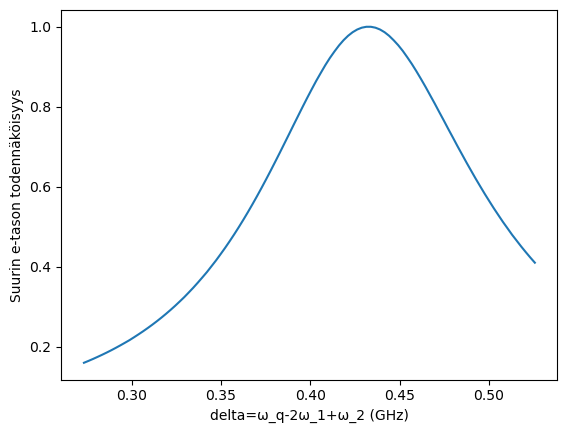

Amplitudi (GHz): 3.1122923801911426
AC-stark siirtymä (GHz): 0.9829776338221131
E-tason suurin todennäköisyys: 0.9996737406418568
Pulssin pituus (ns): 55.14012233353014
Rabi-taajuus (fourier):  0.010577144150697253


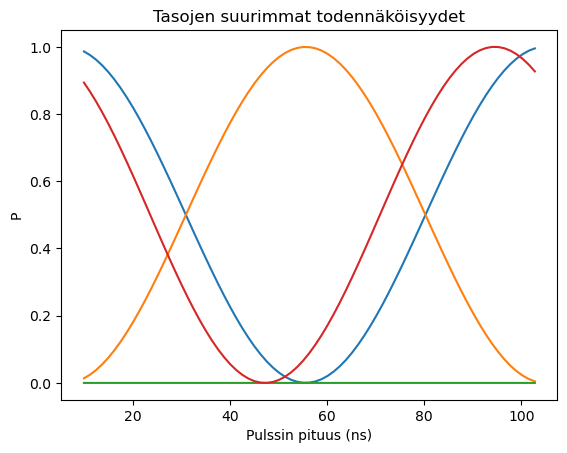

---------------------------------------------


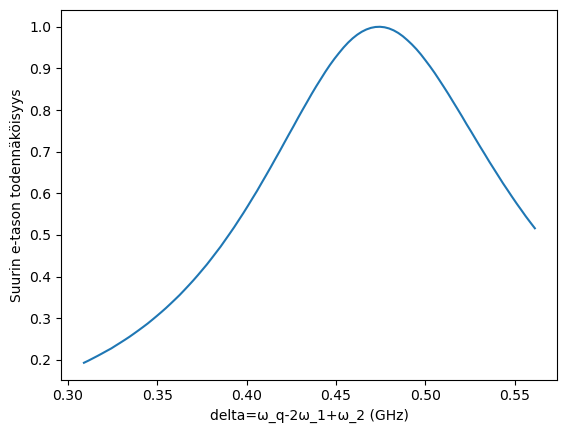

Amplitudi (GHz): 3.2464429138200708
AC-stark siirtymä (GHz): 0.9813774108485682
E-tason suurin todennäköisyys: 0.9999212865752556
Pulssin pituus (ns): 48.934042960996834
Rabi-taajuus (fourier):  0.012156005561051397


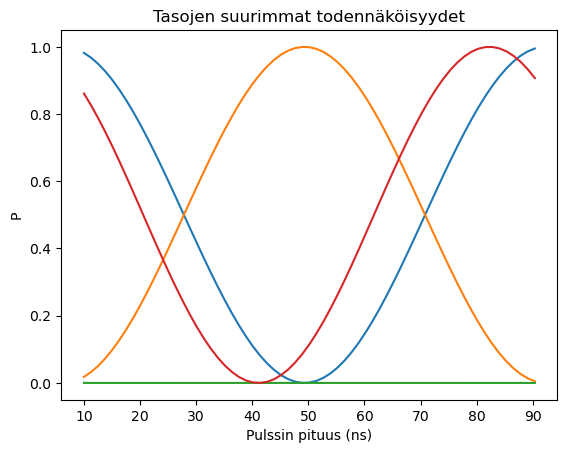

---------------------------------------------


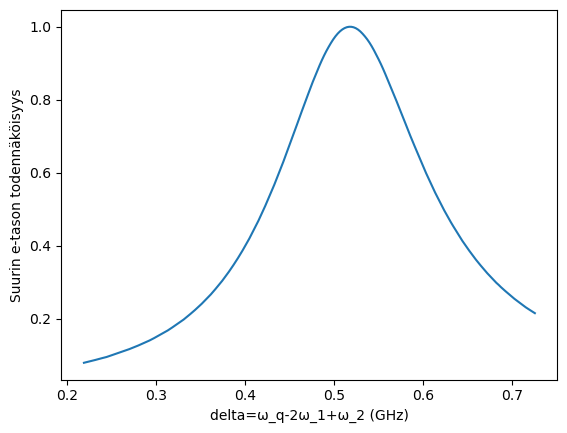

Amplitudi (GHz): 3.380593447449
AC-stark siirtymä (GHz): 0.9797242425672137
E-tason suurin todennäköisyys: 0.9998383860382343
Pulssin pituus (ns): 43.967515077700604
Rabi-taajuus (fourier):  0.013920789904680458


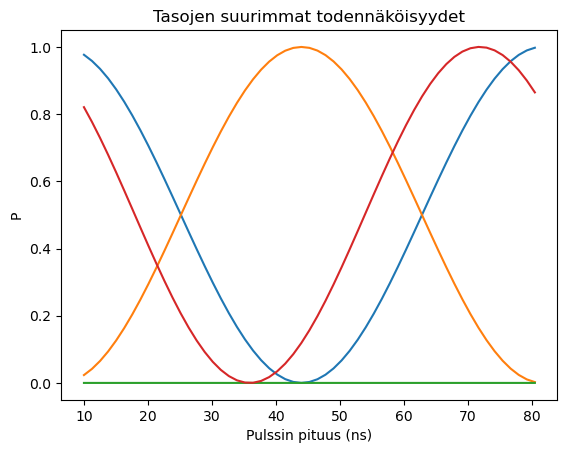

---------------------------------------------


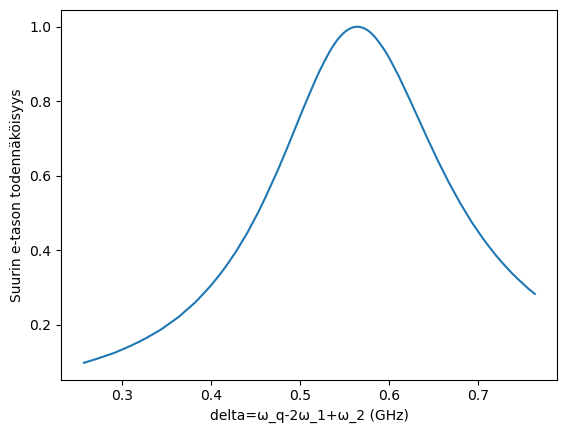

Amplitudi (GHz): 3.514743981077928
AC-stark siirtymä (GHz): 0.9778181289780494
E-tason suurin todennäköisyys: 0.9997562576164055
Pulssin pituus (ns): 38.99169574354217
Rabi-taajuus (fourier):  0.015898409246725205


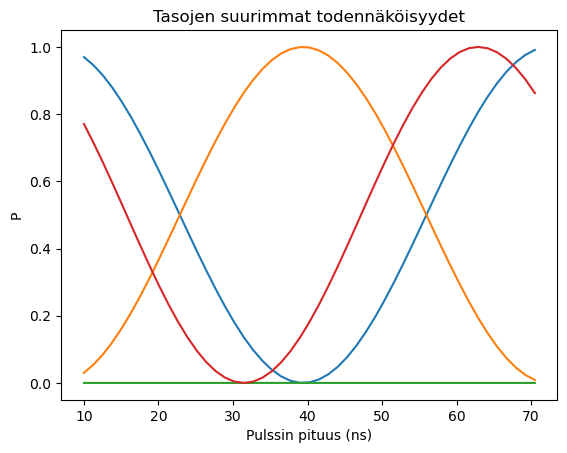

---------------------------------------------


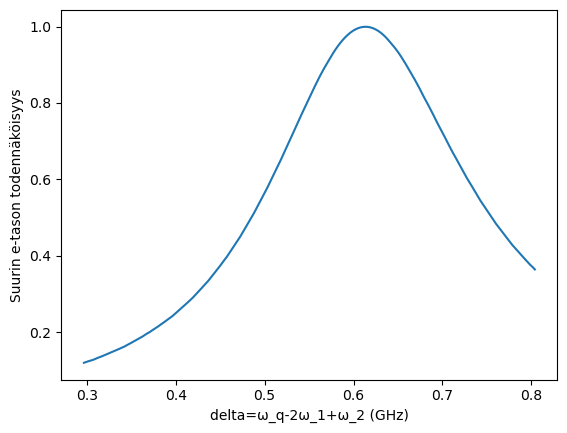

Amplitudi (GHz): 3.648894514706856
AC-stark siirtymä (GHz): 0.9759590700810754
E-tason suurin todennäköisyys: 0.9993785539232128
Pulssin pituus (ns): 35.258191888773524
Rabi-taajuus (fourier):  0.016270321562179883


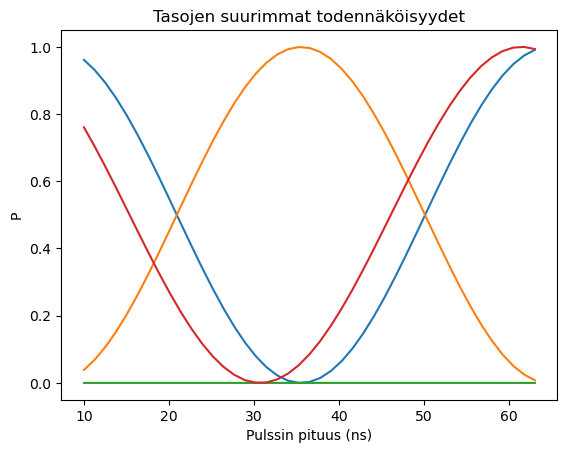

---------------------------------------------


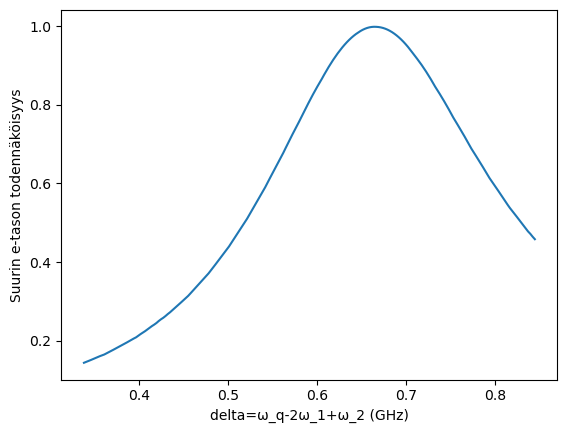

Amplitudi (GHz): 3.783045048335785
AC-stark siirtymä (GHz): 0.9739470658762915
E-tason suurin todennäköisyys: 0.9981825550055154
Pulssin pituus (ns): 32.77933380390211
Rabi-taajuus (fourier):  0.018424117350573768


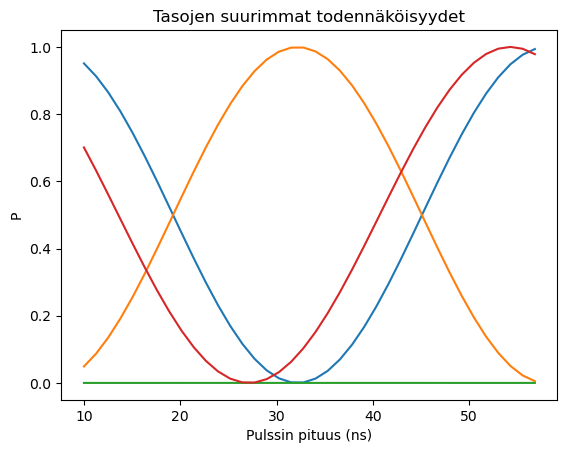

---------------------------------------------


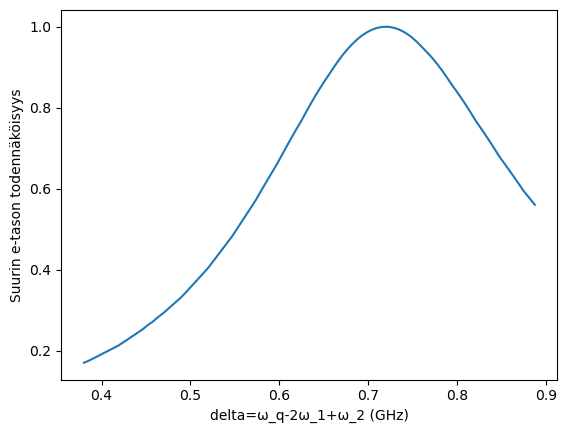

Amplitudi (GHz): 3.9171955819647133
AC-stark siirtymä (GHz): 0.971782116363698
E-tason suurin todennäköisyys: 0.9998157815077047
Pulssin pituus (ns): 29.02506826319615
Rabi-taajuus (fourier):  0.02080909370077517


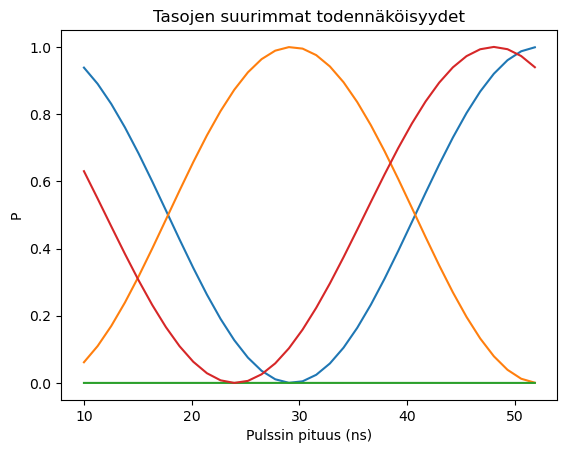

---------------------------------------------


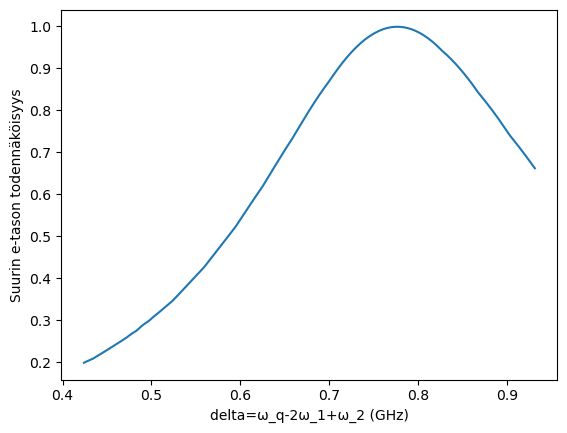

Amplitudi (GHz): 4.051346115593642
AC-stark siirtymä (GHz): 0.9695642215432947
E-tason suurin todennäköisyys: 0.9993683706244628
Pulssin pituus (ns): 26.52610997598307
Rabi-taajuus (fourier):  0.023442735108629237


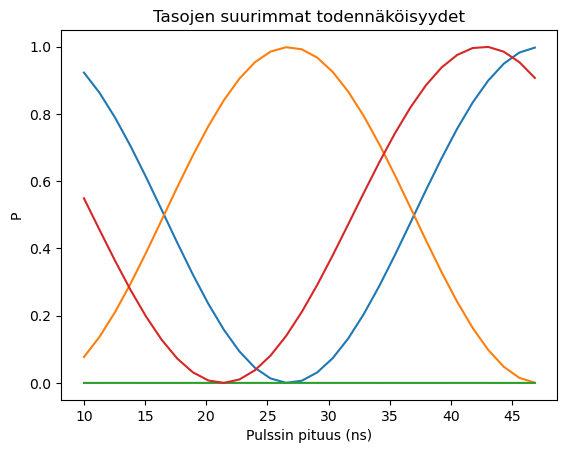

---------------------------------------------


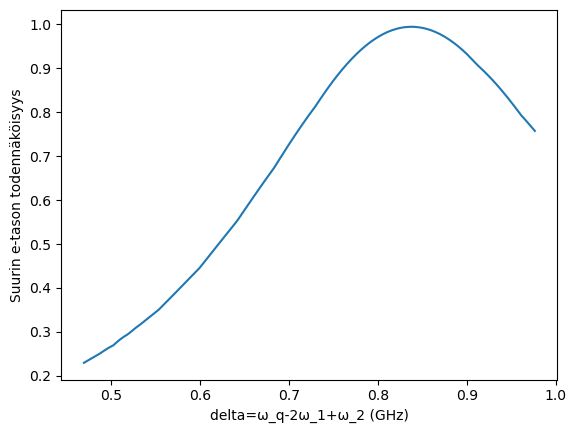

Amplitudi (GHz): 4.1854966492225705
AC-stark siirtymä (GHz): 0.9670933814150816
E-tason suurin todennäköisyys: 0.9946329812377136
Pulssin pituus (ns): 24.019358489864427
Rabi-taajuus (fourier):  0.026349492763288265


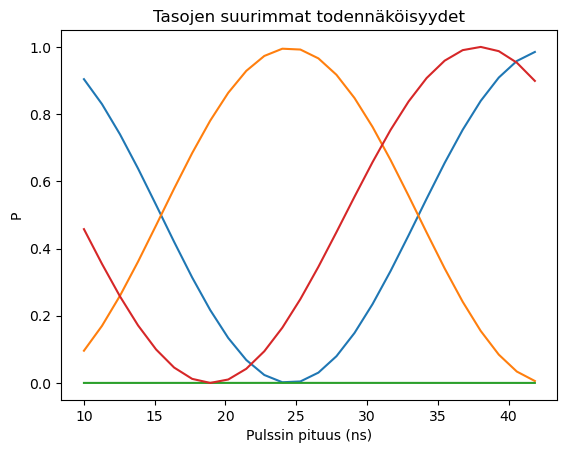

---------------------------------------------


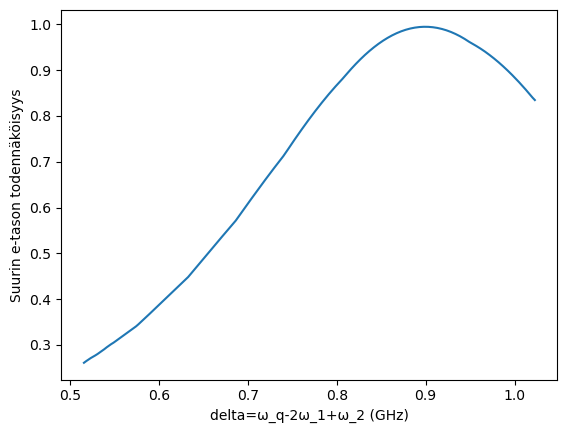

Amplitudi (GHz): 4.3196471828515
AC-stark siirtymä (GHz): 0.9646695959790589
E-tason suurin todennäköisyys: 0.9967453147464388
Pulssin pituus (ns): 22.77689354492307
Rabi-taajuus (fourier):  0.02947265987095389


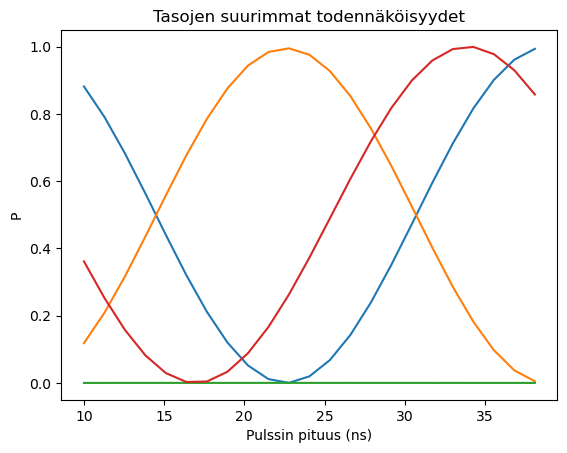

---------------------------------------------


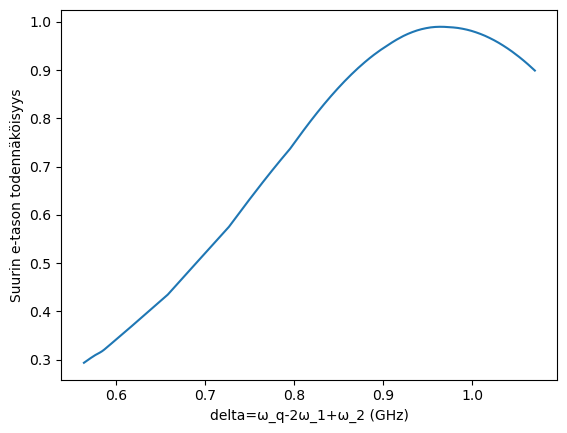

Amplitudi (GHz): 4.453797716480428
AC-stark siirtymä (GHz): 0.9621928652352263
E-tason suurin todennäköisyys: 0.9947810415870135
Pulssin pituus (ns): 21.5288036954542
Rabi-taajuus (fourier):  0.03283121847641836


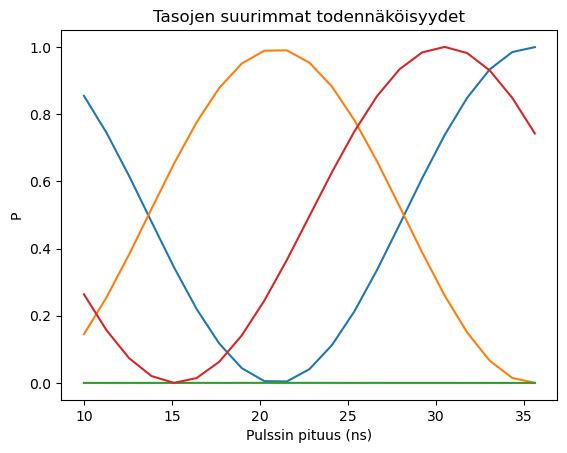

---------------------------------------------


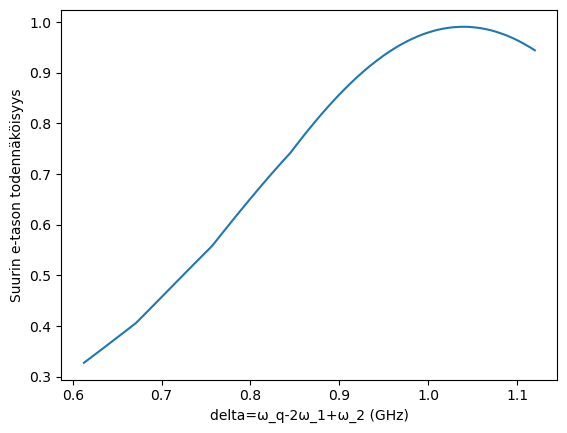

Amplitudi (GHz): 4.587948250109356
AC-stark siirtymä (GHz): 0.9591631891835839
E-tason suurin todennäköisyys: 0.9908624436213866
Pulssin pituus (ns): 18.99517059348125
Rabi-taajuus (fourier):  0.04053100822763104


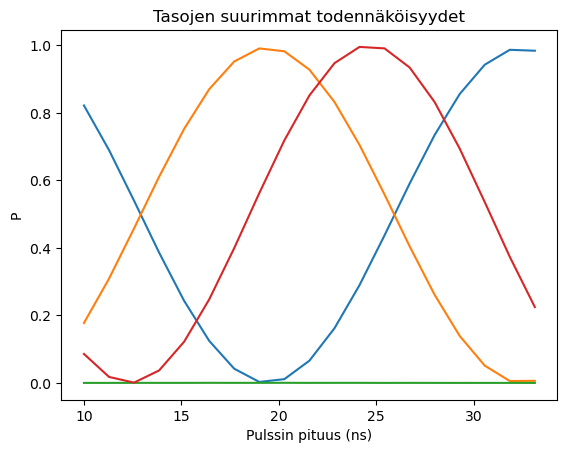

---------------------------------------------


In [ ]:
c_vals = [] #c:n arvot
deltas = [] #AC Stark siirtymät
pulse_lengths = [] #Pulssin pituudet
max_vals = [] #Suurimmat tasojen todennäköisyydet
rabis = [] #Rabi taajuudet (fouriermuunnoksesta)
data = [] #e-tason suurimmat todennäköisyydet amplitudin ja AC-stark siirtymän suhteen
A_vals= []

min_range = 0.08
max_range = 0.18
N_data=20
d_data=(max_range-min_range)/(N_data-1)

for i in range (0,N_data):
    
    A = qubit.frequency*(min_range+i*d_data)
    A_vals.append(A)
    
    f_rabi= 0.0009703*A**3 - 0.00434*A**2 + 0.009973*A - 0.007682 #Arvaus Rabi-taajuudelle
    c=-0.001471*A**2 - 0.001084*A + 1.002 #Arvaus c:n arvolle

    if i<10:
        params=find_params(qubit, A, evolution_eigenbasis,f_rabi*2*np.pi,c,[-50,50],10000)
    else:
        params=find_params(qubit, A, evolution_eigenbasis,f_rabi*2*np.pi,c,[-100,100],10000)

    c_vals.append(params[0])
    pulse_lengths.append(params[1])
    data.append(params[3])
    
    #Löydetyt optimaaliset ajotaajuudet
    f_1_opt = f_1*c_vals[-1]
    f_2_opt = f_2*c_vals[-1]
    deltas.append(qubit.frequency-2*f_1_opt+f_2_opt)

    m=10
    if A < 2.3:
        vals = pulses.sim_3_part_pulses(f_1_opt,f_ef,A,evolution_eigenbasis,dim,(f_rabi*2*np.pi)/m,t_ramp=5,U_f=10,f_2=f_2_opt,K=200)
    elif A < 2.9:
        vals = pulses.sim_3_part_pulses(f_1_opt,f_ef,A,evolution_eigenbasis,dim,(f_rabi*2*np.pi)/m,t_ramp=5,U_f=5,f_2=f_2_opt,K=200)
    else:
        vals = pulses.sim_3_part_pulses(f_1_opt,f_ef,A,evolution_eigenbasis,dim,(f_rabi*2*np.pi)/m,t_ramp=5,U_f=1,f_2=f_2_opt,K=200)
    
    print("Amplitudi (GHz):", A)
    print("AC-stark siirtymä (GHz):", c_vals[-1])

    print("E-tason suurin todennäköisyys:", vals[0])
    print("Pulssin pituus (ns):", pulse_lengths[-1])

    g_vals=np.array([arr[0] for arr in vals[3]])
    e_vals=np.array([arr[1] for arr in vals[3]])
    f_vals=np.array([arr[2] for arr in vals[3]])

    max_vals.append([vals[0],vals[1]])

    g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
    fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

    magnitude = np.abs(fft_vals) #Taajuuskomponentit
    magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

    #Taajuusavaruus
    freqs = np.fft.rfftfreq(len(g_vals), d=vals[4][1]-vals[4][0]) 
    frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
    print("Rabi-taajuus (fourier): ",frequency)
    rabis.append(frequency)

    n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä
    
    plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

    plt.figure()
    plt.plot(vals[4][:n_picked], g_vals[:n_picked])
    plt.plot(vals[4][:n_picked], e_vals[:n_picked])
    plt.plot(vals[4][:n_picked], f_vals[:n_picked])
    plt.plot(vals[4][:n_picked], plot_vals)
    plt.xlabel("Pulssin pituus (ns)")
    plt.ylabel("P")
    plt.title("Tasojen suurimmat todennäköisyydet")
    plt.show()

    print("---------------------------------------------")

[np.float64(2.039088111159714), np.float64(2.1732386447886425), np.float64(2.307389178417571), np.float64(2.4415397120464997), np.float64(2.575690245675428), np.float64(2.7098407793043564), np.float64(2.8439913129332854), np.float64(2.9781418465622136), np.float64(3.1122923801911426), np.float64(3.2464429138200708), np.float64(3.380593447449), np.float64(3.514743981077928), np.float64(3.648894514706856), np.float64(3.783045048335785), np.float64(3.9171955819647133), np.float64(4.051346115593642), np.float64(4.1854966492225705), np.float64(4.3196471828515), np.float64(4.453797716480428), np.float64(4.587948250109356)]


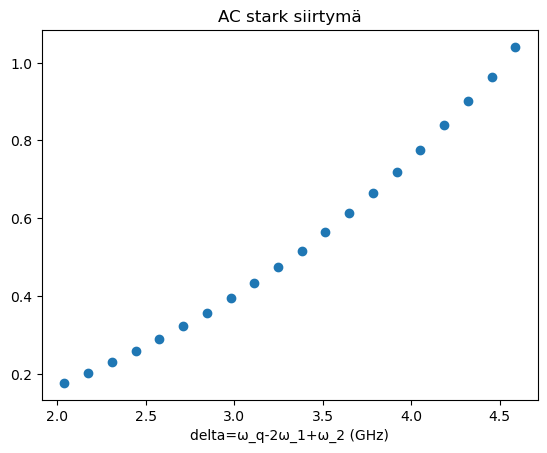

[np.float64(0.1765496897332568), np.float64(0.20144340019270857), np.float64(0.23023547263730393), np.float64(0.25782818678916897), np.float64(0.2893192629261776), np.float64(0.3221598409094), np.float64(0.356349920738829), np.float64(0.3944383625534158), np.float64(0.43387630621420215), np.float64(0.47466375172120934), np.float64(0.516800699074409), np.float64(0.5653848685517175), np.float64(0.6127696797362887), np.float64(0.6640528529060106), np.float64(0.7192343880608973), np.float64(0.7757654250619836), np.float64(0.8387436841871789), np.float64(0.9005225850196297), np.float64(0.963650987698287), np.float64(1.040873192917907)]
[np.float64(0.9930733865293206), np.float64(0.9920967260182538), np.float64(0.9909671201993773), np.float64(0.989884569072691), np.float64(0.9886490726381949), np.float64(0.9873606308958891), np.float64(0.9860192438457734), np.float64(0.9845249114878482), np.float64(0.9829776338221131), np.float64(0.9813774108485682), np.float64(0.9797242425672137), np.float6

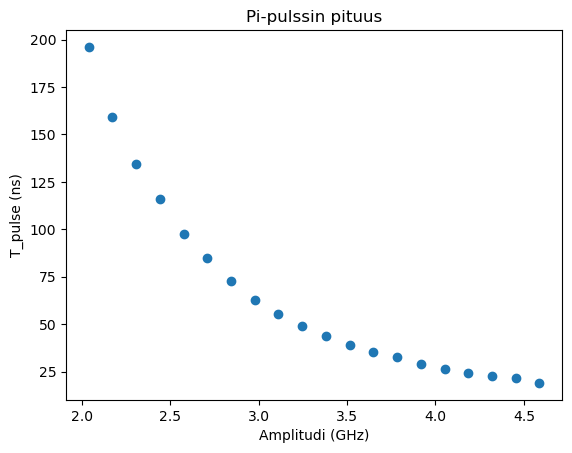

[np.float64(196.17175076443056), np.float64(159.0840206678187), np.float64(134.37830158652045), np.float64(115.83717486964673), np.float64(97.26894863382229), np.float64(84.89956768479678), np.float64(72.50121795683864), np.float64(62.58071022695719), np.float64(55.14012233353014), np.float64(48.934042960996834), np.float64(43.967515077700604), np.float64(38.99169574354217), np.float64(35.258191888773524), np.float64(32.77933380390211), np.float64(29.02506826319615), np.float64(26.52610997598307), np.float64(24.019358489864427), np.float64(22.77689354492307), np.float64(21.5288036954542), np.float64(18.99517059348125)]


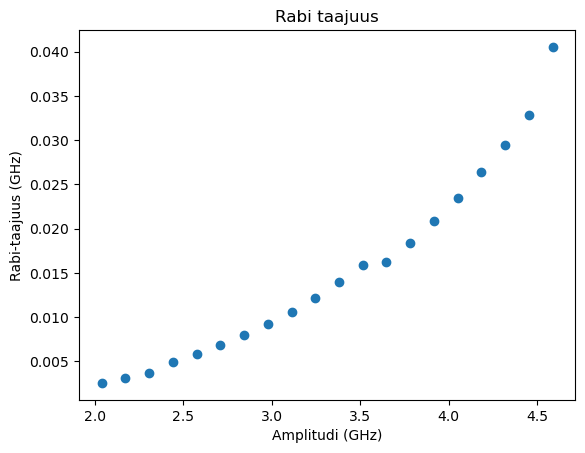

[np.float64(0.002553298826079879), np.float64(0.0031091146537931837), np.float64(0.003729891145446168), np.float64(0.004927119353670419), np.float64(0.005812449728711454), np.float64(0.006788751817781148), np.float64(0.00792063772728974), np.float64(0.009160229560761141), np.float64(0.010577144150697253), np.float64(0.012156005561051397), np.float64(0.013920789904680458), np.float64(0.015898409246725205), np.float64(0.016270321562179883), np.float64(0.018424117350573768), np.float64(0.02080909370077517), np.float64(0.023442735108629237), np.float64(0.026349492763288265), np.float64(0.02947265987095389), np.float64(0.03283121847641836), np.float64(0.04053100822763104)]


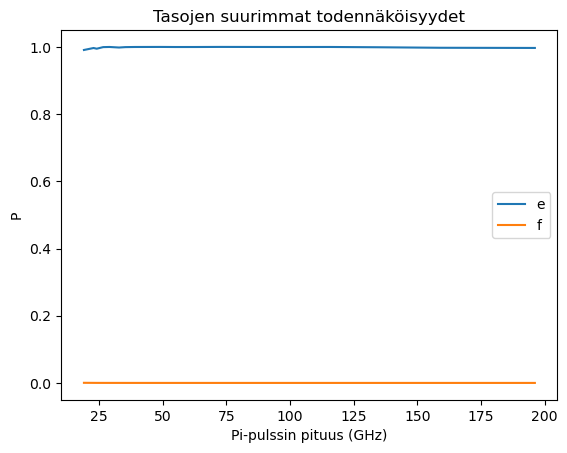

[np.float64(0.9969169160461923), np.float64(0.9974480739983631), np.float64(0.9989779966907044), np.float64(0.999795415969553), np.float64(0.999719281498736), np.float64(0.9998386946345065), np.float64(0.9999632528679934), np.float64(0.9996990712609413), np.float64(0.9996737406418568), np.float64(0.9999212865752556), np.float64(0.9998383860382343), np.float64(0.9997562576164055), np.float64(0.9993785539232128), np.float64(0.9981825550055154), np.float64(0.9998157815077047), np.float64(0.9993683706244628), np.float64(0.9946329812377136), np.float64(0.9967453147464388), np.float64(0.9947810415870135), np.float64(0.9908624436213866)]
[np.float64(6.241173135372756e-07), np.float64(8.026187270850263e-07), np.float64(1.0475570968279812e-06), np.float64(1.3667906379524483e-06), np.float64(1.8394476908054848e-06), np.float64(2.4708653202411404e-06), np.float64(3.3245082951894205e-06), np.float64(4.605883748930216e-06), np.float64(6.3426141814828746e-06), np.float64(8.664911447438682e-06), np.f

'\nplt.figure(figsize=(6, 6))\nplt.imshow(data, aspect=\'auto\')  # stretches to square\nplt.colorbar(label="e-tason suurin todennäköisyys")\nplt.show() '

In [7]:
print(A_vals)

plt.figure()
plt.plot(A_vals, deltas, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.xlabel("delta=ω_q-2ω_1+ω_2 (GHz)")
plt.title("AC stark siirtymä")
plt.show()
print(deltas)
print(c_vals)

plt.figure()
plt.plot(A_vals, pulse_lengths, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("T_pulse (ns)")
plt.title("Pi-pulssin pituus")
plt.show()
print(pulse_lengths)

plt.figure()
plt.plot(A_vals, rabis, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("Rabi-taajuus (GHz)")
plt.title("Rabi taajuus")
plt.show()
print(rabis)

e_vals=[arr[0] for arr in max_vals]
f_vals=[arr[1] for arr in max_vals]

plt.figure()
plt.plot(pulse_lengths, e_vals)
plt.plot(pulse_lengths, f_vals)
plt.legend(["e","f"])
plt.xlabel("Pi-pulssin pituus (GHz)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()
print(e_vals)
print(f_vals)

"""
plt.figure(figsize=(6, 6))
plt.imshow(data, aspect='auto')  # stretches to square
plt.colorbar(label="e-tason suurin todennäköisyys")
plt.show() """